In [1]:
import moocore
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import moocore

In [31]:
df = pd.read_csv('results.csv')
df

,model,dataset,fold,hit_rate,ndcg,mrr
0,AE_BPR,Amazon,0.0,0.286319,0.173250,0.155317
1,AE_BPR,Amazon,1.0,0.309984,0.190472,0.170022
2,AE_BPR,Amazon,2.0,0.308972,0.190988,0.170490
3,AE_BPR,Amazon,3.0,0.306447,0.189243,0.169644
4,AE_BPR,Amazon,4.0,0.297218,0.184428,0.167026
...,...,...,...,...,...,...
190,ConvMF,Rotten Tomatoes,1.0,0.178283,0.089859,0.086325
191,ConvMF,Rotten Tomatoes,3.0,0.180769,0.092536,0.088377
192,ConvMF,Rotten Tomatoes,2.0,0.181538,0.089625,0.084795
193,ConvMF,Rotten Tomatoes,4.0,0.173010,0.090038,0.087856


--- Teste de Normalidade (Global) ---
Shapiro-Wilk: p-value = 2.7294e-25 (Não-Normal)

Número de blocos (Dataset + Folds) analisados: 15
Modelos comparados: ['AE_BPR', 'CARL', 'ConvMF', 'DAML', 'DeepCoNN', 'GHC2F_Text', 'GHC2F_Topic', 'GHCF_Text', 'GHCF_Topic', 'GRAFT', 'KANN', 'LETTER', 'TARMF']

--- Teste de Friedman (Todos os Datasets) ---
Estatística: 144.5538
p-value: 7.1948e-25

--- Ranking Médio Global ---
model
GHCF_Topic      1.866667
AE_BPR          2.933333
GHC2F_Topic     3.400000
GHCF_Text       4.333333
LETTER          4.466667
CARL            6.600000
GHC2F_Text      7.133333
TARMF           7.400000
DAML            8.800000
ConvMF          9.266667
DeepCoNN        9.866667
GRAFT          12.266667
KANN           12.666667
dtype: float64 



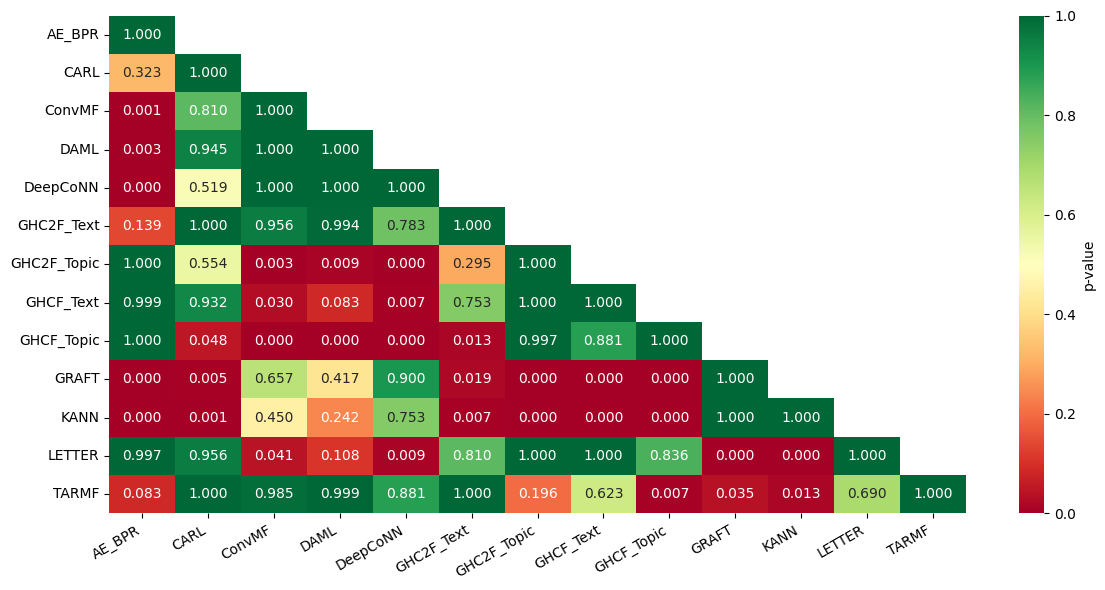

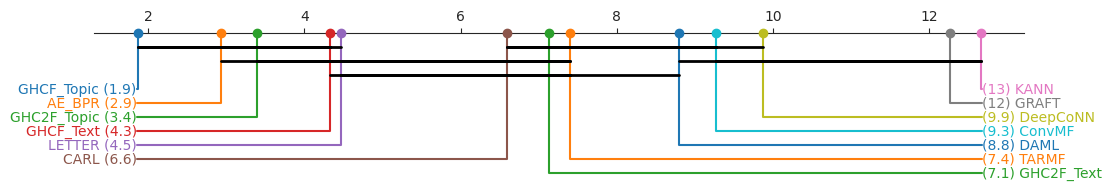

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, friedmanchisquare
import scikit_posthocs as sp




# Cálculo do Hypervolume (Produto das métricas de maximização)
def calculate_hv(row):
    ref_point = np.array([0.0, 0.0, 0.0]) # [hr@10, ndcg@10, mrr]
    ind = moocore.Hypervolume(ref=ref_point, maximise=True)
    return ind(np.array([[row['hit_rate'], row['ndcg'], row['mrr']]]))

df['HV'] = df.apply(calculate_hv, axis=1)

# 2. Teste de Normalidade Global (Shapiro-Wilk)
stat, p_norm = shapiro(df['HV'])
print(f"--- Teste de Normalidade (Global) ---")
print(f"Shapiro-Wilk: p-value = {p_norm:.4e} ({'Normal' if p_norm > 0.05 else 'Não-Normal'})\n")

# 3. Preparação da Matriz de Friedman (Considerando Todos os Datasets)
# Criamos uma chave única combinando Dataset e Fold para serem nossos 'blocos'
df['block'] = df['dataset'] + "_f" + df['fold'].astype(str)

# Pivotamos: Linhas são as combinações Dataset/Fold, Colunas são os Modelos
pivot_df = df.pivot_table(index='block', columns='model', values='HV')

# O Friedman exige que não haja NaNs. Vamos remover blocos onde nem todos os modelos rodaram
pivot_df = pivot_df.dropna()

print(f"Número de blocos (Dataset + Folds) analisados: {len(pivot_df)}")
print(f"Modelos comparados: {list(pivot_df.columns)}\n")

# 4. Teste de Friedman
stat_f, p_f = friedmanchisquare(*[pivot_df[col] for col in pivot_df.columns])
print(f"--- Teste de Friedman (Todos os Datasets) ---")
print(f"Estatística: {stat_f:.4f}")
print(f"p-value: {p_f:.4e}\n")

# 5. Post-hoc Nemenyi e Visualizações
if p_f < 0.05:
    # Detalhamento do Rank (Maiores valores de HV recebem os melhores postos)
    # rank(ascending=False) garante que o maior HV seja rank 1
    ranks = pivot_df.rank(axis=1, ascending=False).mean().sort_values()
    print("--- Ranking Médio Global ---")
    print(ranks, "\n")

    # Cálculo da Matriz de Nemenyi
    nemenyi_matrix = sp.posthoc_nemenyi_friedman(pivot_df)

    # PLOT 1: Mapa de Calor da Matriz de Nemenyi
    plt.figure(figsize=(12, 6))
    plt.rcdefaults()
    sns.heatmap(nemenyi_matrix, annot=True, cmap='RdYlGn', fmt=".3f",
                cbar_kws={'label': 'p-value'}, mask=np.triu(np.ones_like(nemenyi_matrix, dtype=bool), k=1))
    sns.set_style("white")
    # plt.title('Matriz de Nemenyi: p-values (Comparação Global entre Modelos)')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig('matriz_nemenyi.pdf', dpi=300)
    plt.show()

    # PLOT 2: Gráfico de Diferença Crítica (CD Diagram)
    # Este gráfico é o mais importante para visualizar a performance entre datasets
    plt.figure(figsize=(12, 2))
    sp.critical_difference_diagram(ranks, nemenyi_matrix)
    #plt.title("Diagrama de Diferença Crítica (CD) - Todos os Datasets")
    plt.savefig('diagrama_dc.pdf', dpi=300,bbox_inches='tight')
    plt.show()
else:
    print("O teste de Friedman não encontrou diferenças significativas entre os modelos considerando todos os datasets.")

In [6]:
import pandas as pd
import copy
# 1. Carregar os arquivos
# pivot_df = copy.deepcopy(pivot_df)
ranks_df = pivot_df.rank(axis=1, ascending=False)

# Limpeza: Remover possíveis '\n' nos nomes das colunas que vêm do CSV
pivot_df.columns = pivot_df.columns.str.replace('\n', '', regex=False)
ranks_df.columns = ranks_df.columns.str.replace('\n', '', regex=False)

# Garantir que o índice seja a coluna de modelos/blocos
#pivot_df = pivot_df.set_index('block')
#ranks_df = ranks_df.set_index('block')

# 2. Criar o DataFrame mesclado
# Usamos o .applymap (ou .map em versões novas) para iterar sobre as células
merged_df = pivot_df.copy()

colunas_ordenada = pivot_df.rank(axis=1, ascending=False).mean().sort_values().index.values

for col in colunas_ordenada:
    # Arredonda pivot e converte rank para inteiro (formatado como string)
    merged_df[col] = (
        pivot_df[col].map('{:.4f}'.format) +
        " (" +
        ranks_df[col].astype(int).astype(str) + "º)"
    )
merged_df_ordenado = merged_df[pivot_df.rank(axis=1, ascending=False).mean().sort_values().index.values]
# 3. Salvar o resultado
merged_df_ordenado.to_csv('tabela_final.csv')
merged_df_ordenado

model,GHCF_Topic,AE_BPR,GHC2F_Topic,GHCF_Text,LETTER,CARL,GHC2F_Text,TARMF,DAML,ConvMF,DeepCoNN,GRAFT,KANN
block,,,,,,,,,,,,,
Amazon_f0.0,0.0053 (2º),0.0077 (1º),0.0044 (3º),0.0043 (4º),0.0033 (5º),0.0008 (9º),0.0014 (6º),0.0009 (8º),0.0012 (7º),0.0005 (10º),0.0004 (11º),0.0001 (13º),0.0001 (12º)
Amazon_f1.0,0.0066 (2º),0.0100 (1º),0.0049 (4º),0.0057 (3º),0.0011 (10º),0.0016 (8º),0.0016 (9º),0.0049 (5º),0.0025 (7º),0.0010 (11º),0.0047 (6º),0.0001 (13º),0.0002 (12º)
Amazon_f2.0,0.0068 (2º),0.0101 (1º),0.0061 (3º),0.0060 (4º),0.0014 (10º),0.0018 (7º),0.0017 (9º),0.0050 (5º),0.0017 (8º),0.0043 (6º),0.0009 (11º),0.0001 (13º),0.0002 (12º)
Amazon_f3.0,0.0071 (3º),0.0098 (1º),0.0062 (4º),0.0061 (5º),0.0011 (9º),0.0018 (7º),0.0020 (6º),0.0073 (2º),0.0017 (8º),0.0011 (10º),0.0007 (11º),0.0001 (13º),0.0002 (12º)
Amazon_f4.0,0.0064 (3º),0.0092 (1º),0.0061 (4º),0.0060 (5º),0.0011 (10º),0.0019 (6º),0.0018 (7º),0.0073 (2º),0.0016 (8º),0.0014 (9º),0.0007 (11º),0.0001 (13º),0.0002 (12º)
IMDb_f0.0,0.0028 (2º),0.0014 (4º),0.0012 (5º),0.0016 (3º),0.0048 (1º),0.0010 (6º),0.0005 (8º),0.0004 (11º),0.0005 (10º),0.0007 (7º),0.0005 (9º),0.0002 (12º),0.0001 (13º)
IMDb_f1.0,0.0031 (2º),0.0012 (4º),0.0011 (5º),0.0013 (3º),0.0043 (1º),0.0011 (6º),0.0006 (8º),0.0008 (7º),0.0004 (11º),0.0005 (9º),0.0005 (10º),0.0003 (12º),0.0002 (13º)
IMDb_f2.0,0.0025 (2º),0.0010 (6º),0.0011 (5º),0.0013 (3º),0.0047 (1º),0.0011 (4º),0.0007 (7º),0.0006 (8º),0.0005 (11º),0.0005 (10º),0.0006 (9º),0.0003 (12º),0.0001 (13º)
IMDb_f3.0,0.0034 (2º),0.0012 (3º),0.0009 (5º),0.0009 (6º),0.0046 (1º),0.0010 (4º),0.0007 (8º),0.0006 (9º),0.0005 (11º),0.0007 (7º),0.0006 (10º),0.0003 (12º),0.0001 (13º)


/tmp/ipykernel_318024/2133312990.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')


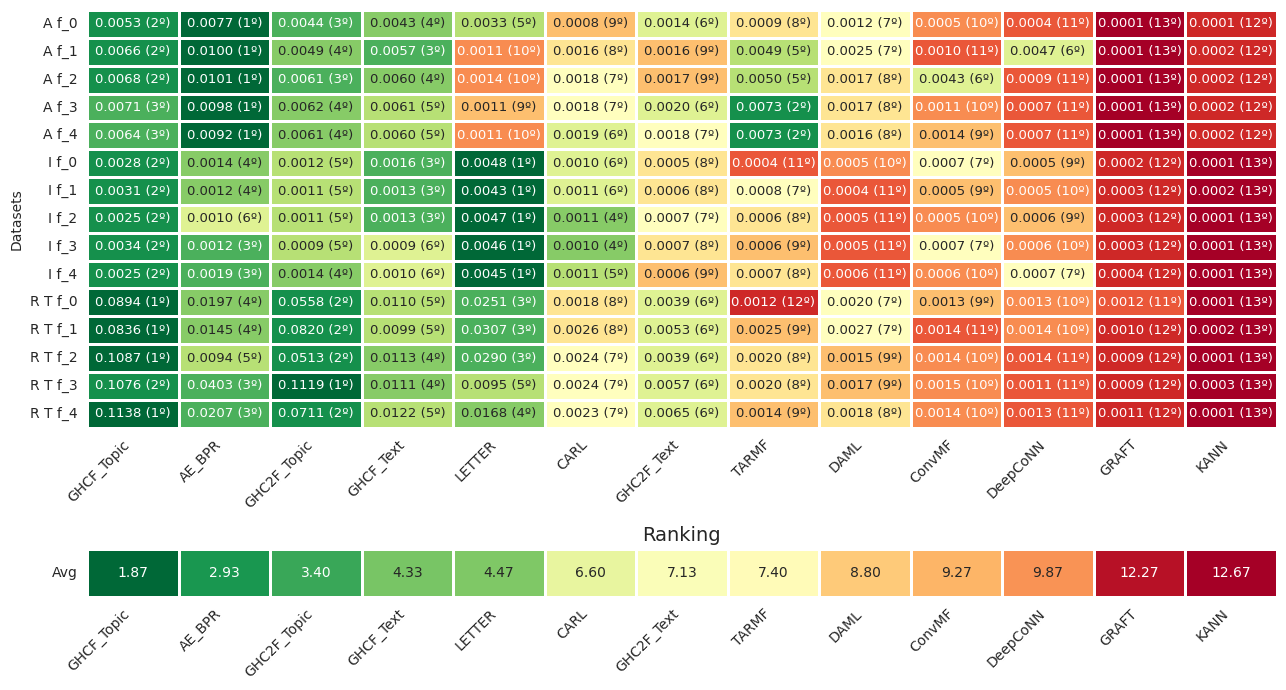

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

# 1. Carregar e tratar os dados
df = pd.read_csv('tabela_final.csv')
df.columns = [col.strip().replace('\n', '') for col in df.columns]
df.set_index(df.columns[0], inplace=True)

def extract_rank(val):
    match = re.search(r'\((\d+)º\)', str(val))
    return int(match.group(1)) if match else 0

rank_df = df.apply(lambda col: col.map(extract_rank))

# 2. Calcular Ranking Médio e ordenar colunas (da melhor média para a pior)
ranking_medio = rank_df.mean().sort_values()
rank_df_ordenado = rank_df[ranking_medio.index]
df_ordenado = df[ranking_medio.index]

# Criar um DataFrame de uma linha para o segundo Heatmap (as médias)
mean_df = pd.DataFrame(ranking_medio).T
mean_df.index = ['Média Geral']

# 3. Plotagem
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7),
                               gridspec_kw={'height_ratios': [7, 0.8]})

# --- Heatmap 1: Detalhado ---
sns.heatmap(rank_df_ordenado, annot=df_ordenado.values, fmt="", cmap='RdYlGn_r',
            linewidths=0.8, ax=ax1, cbar=False, annot_kws={"size": 9.5}) # Cbar removido para limpar o visual
#ax1.set_title('Ranking Detalhado por Dataset', fontsize=16, pad=15)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax1.set_ylabel('Datasets')
# --- Heatmap 2: Média (Consolidado) ---
sns.heatmap(mean_df, annot=True, fmt=".2f", cmap='RdYlGn_r',
            linewidths=0.8, ax=ax2, cbar=False, annot_kws={"size": 10})
ax2.set_title('Ranking', fontsize=14)
ax2.set_yticklabels(['Avg'], rotation=0)

plt.tight_layout()
plt.savefig('heatmap_duplo_ranking.pdf', dpi=300)
plt.show()